 Libraries I need for working with the data, making charts,
 doing statistical tests, and building the ML models.

In [64]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
# Keep the plots easy to read
sns.set_theme(style="whitegrid")

 Load the diabetes data first and take a quick look at
 the size, columns, rows, and basic statistics.

In [65]:
data = pd.read_csv("../data/diabetes.csv")
print("dataset shape:", data.shape)
print("\ncolumn names:")
print(data.columns.tolist())
print("\nfirst 5 rows:")
print(data.head())
print("\nlast 5 rows:")
print(data.tail())
print("\ndataset information:")
print(data.info())
print("\ndescriptive statistics:")
print(data.describe())

dataset shape: (768, 9)

column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

first 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

last 5 rows:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101           

 Before starting the analysis, I want to check if there are
 missing values, duplicate rows, or anything unusual in the data.

In [66]:
print("Missing values:")
print(data.isnull().sum())

print("\nduplicate rows:", data.duplicated().sum())

print("\ndata types:")
print(data.dtypes)

print("\nunique values:")
print(data.nunique())

print("\nrows with zero values:")
zero_counts = (data == 0).sum()
print(zero_counts)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

duplicate rows: 0

data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

unique values:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

rows with zer

 Outcome is the value I want to predict.
First I want to see how many records belong to each class
 and what the probability of each class looks like.

Outcome counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Probablity of no diabets: 0.6510416666666666
Probablity of diabets: 0.3489583333333333


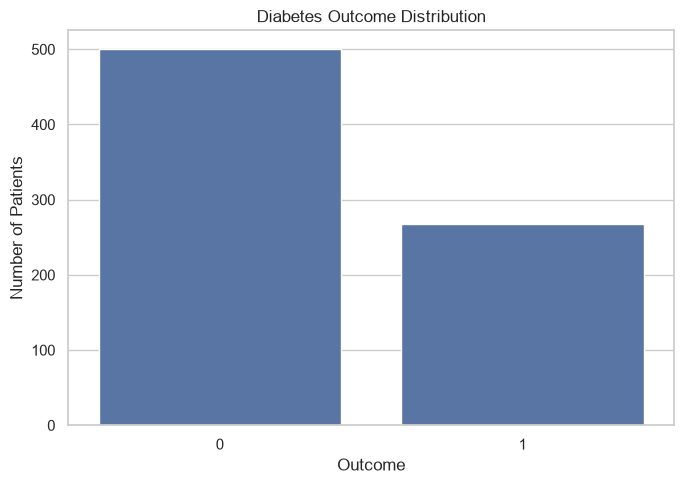

In [67]:
print("Outcome counts:")
print(data["Outcome"].value_counts())
print("\nOutcome proportions:")
print(data["Outcome"].value_counts(normalize=True))
probability_no_diabetes = (data["Outcome"] == 0).mean()
probability_diabetes = (data["Outcome"] == 1).mean()
print("\nProbablity of no diabets:", probability_no_diabetes)
print("Probablity of diabets:", probability_diabetes)
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="Outcome")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("../charts/outcome_distribution.png", dpi=300)
plt.show()

 I want to look at the main statistics of some important
 health features before moving to machine learning.

In [68]:
features_to_analyze = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age",
    "Insulin"
]
for column in features_to_analyze:
    values = data[column].to_numpy()
    print("\n" + "=" * 20)
    print(column)
    print("=" * 20)
    print("Mean:", np.mean(values))
    print("Median:", np.median(values))
    print("Standard deviation:", np.std(values))
    print("Minimum:", np.min(values))
    print("Maximum:", np.max(values))
    print("25th percentile:", np.percentile(values, 25))
    print("75th percentile:", np.percentile(values, 75))


Glucose
Mean: 120.89453125
Median: 117.0
Standard deviation: 31.95179590820272
Minimum: 0
Maximum: 199
25th percentile: 99.0
75th percentile: 140.25

BloodPressure
Mean: 69.10546875
Median: 72.0
Standard deviation: 19.343201628981696
Minimum: 0
Maximum: 122
25th percentile: 62.0
75th percentile: 80.0

BMI
Mean: 31.992578124999998
Median: 32.0
Standard deviation: 7.87902573154013
Minimum: 0.0
Maximum: 67.1
25th percentile: 27.3
75th percentile: 36.6

Age
Mean: 33.240885416666664
Median: 29.0
Standard deviation: 11.752572645994181
Minimum: 21
Maximum: 81
25th percentile: 24.0
75th percentile: 41.0

Insulin
Mean: 79.79947916666667
Median: 30.5
Standard deviation: 115.16894926467262
Minimum: 0
Maximum: 846
25th percentile: 0.0
75th percentile: 127.25


 Now I want to see how the values are distributed
 and whether the two outcome groups look different

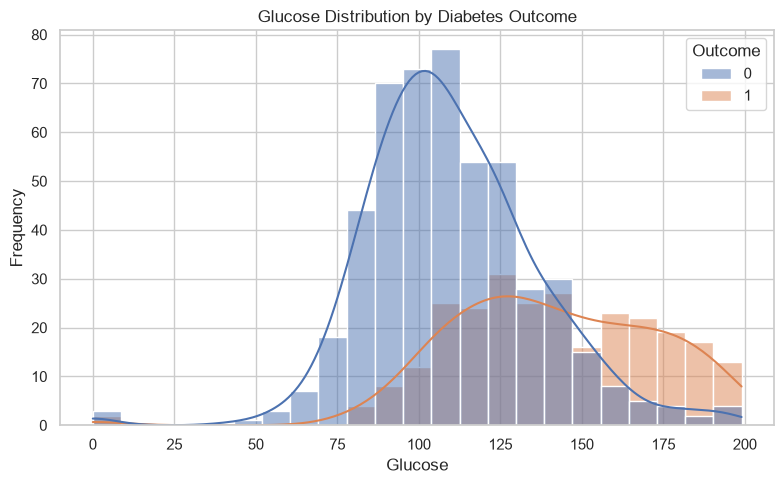

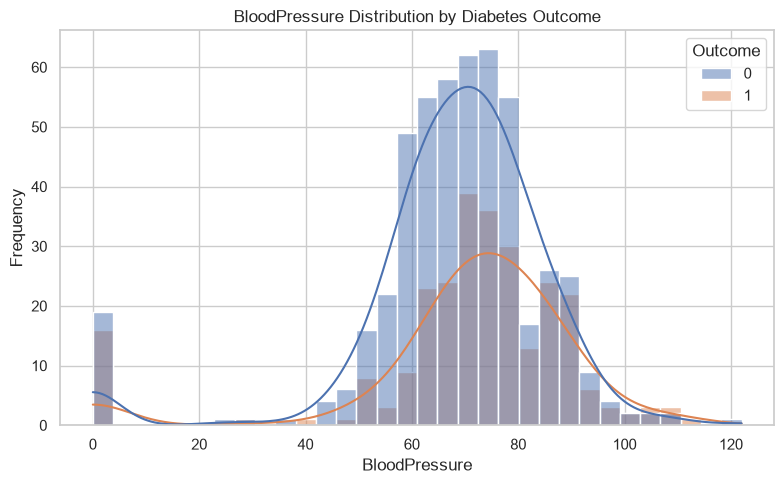

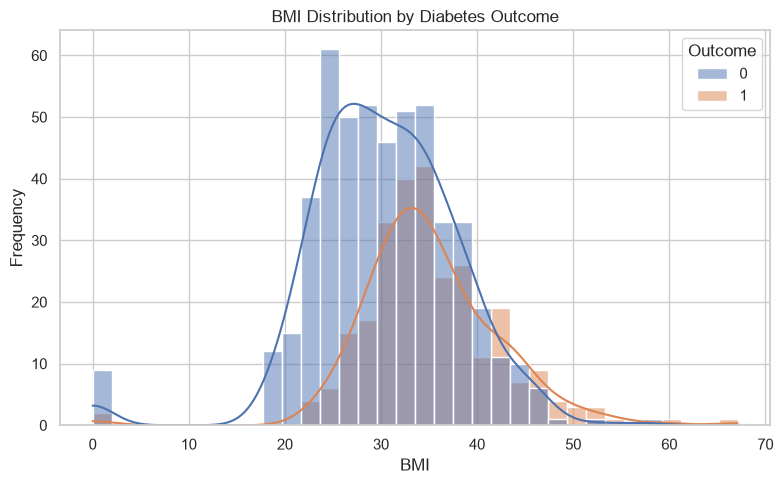

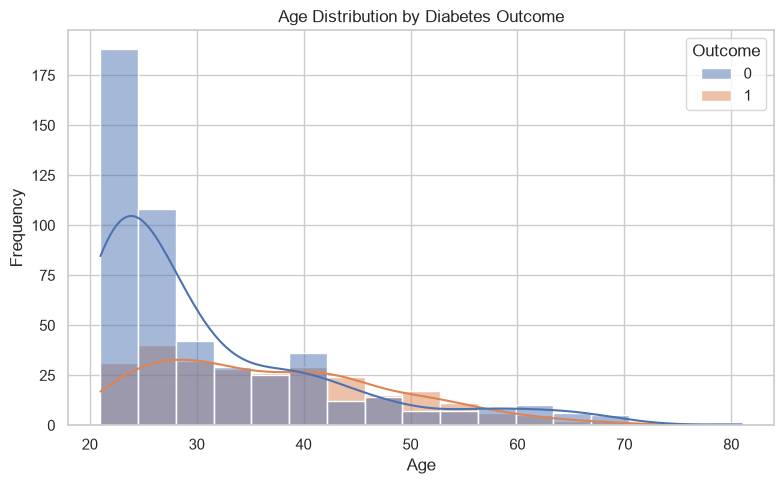

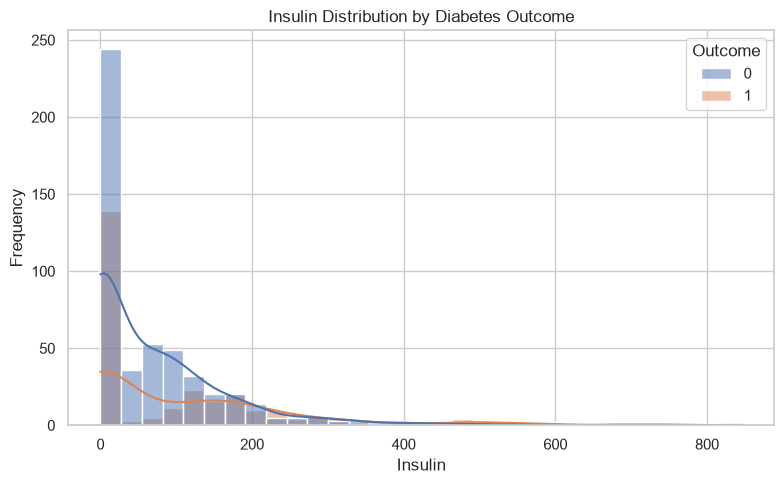

In [70]:
features_to_plot = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age",
    "Insulin"
]
for column in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=data,
        x=column,
        hue="Outcome",
        kde=True
    )
    plt.title(f"{column} Distribution by Diabetes Outcome")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(
        f"../charts/{column.lower()}_distribution.png",
        dpi=300
    )
    plt.show()

 Boxplots help me see the spread of each feature and
 also give me an idea about possible outliers.

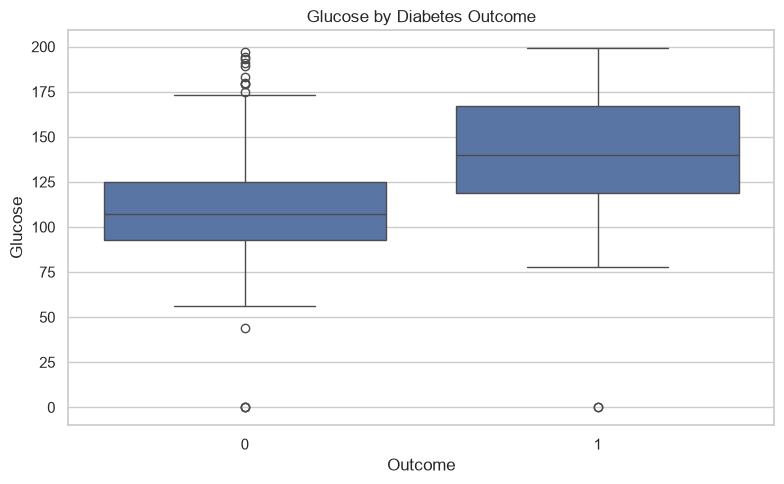

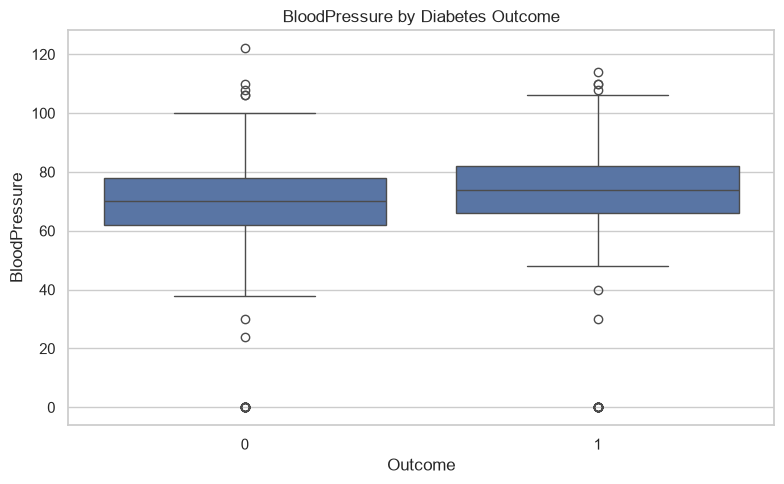

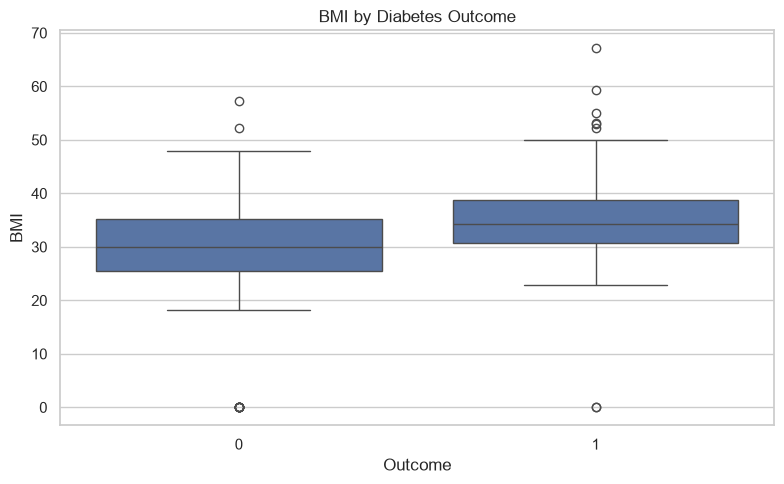

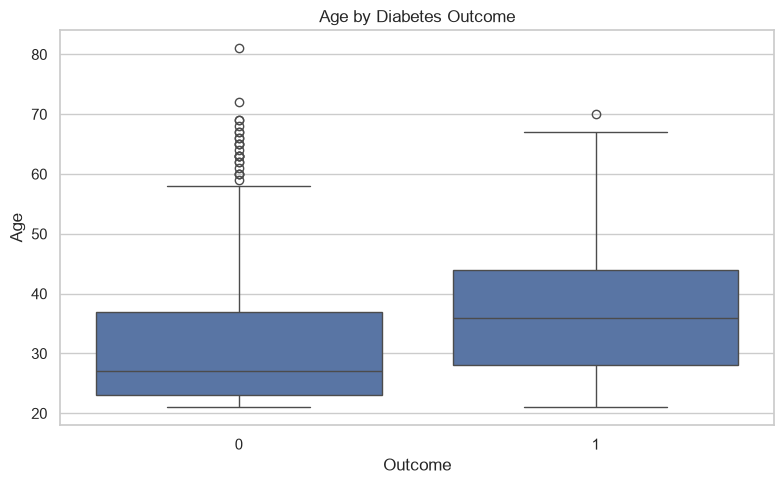

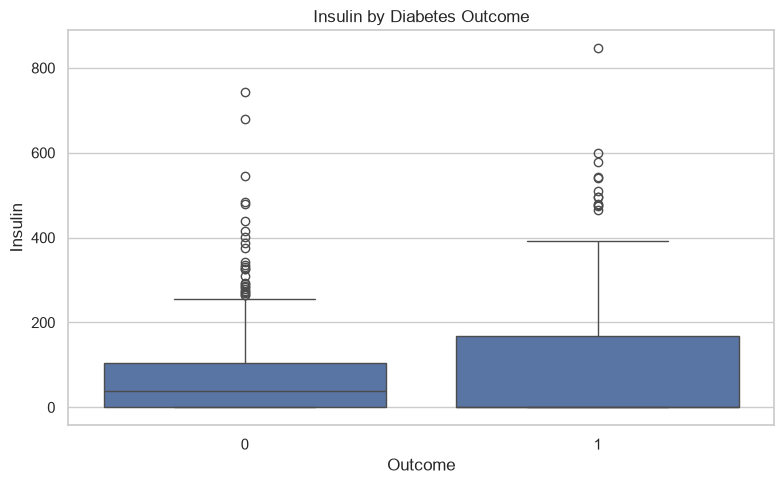


outlier analysis
Glucose: 5 potential outliers
BloodPressure: 45 potential outliers
BMI: 19 potential outliers
Age: 9 potential outliers
Insulin: 34 potential outliers


In [71]:
features_to_plot = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age",
    "Insulin"
]
for column in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=data,
        x="Outcome",
        y=column
    )
    plt.title(f"{column} by Diabetes Outcome")
    plt.xlabel("Outcome")
    plt.ylabel(column)
    plt.tight_layout()
    plt.savefig(
        f"../charts/{column.lower()}_boxplot.png",
        dpi=300
    )
    plt.show()
#  by using Using the IQR rule to count possible outliers in each feature.
print("\noutlier analysis")
print("=" * 19)
for column in features_to_plot:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    print(
        f"{column}: {len(outliers)} potential outliers"
    )

 I want to check how the numerical features are related
 to each other and especially how they relate to Outcome.

Correlation matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00


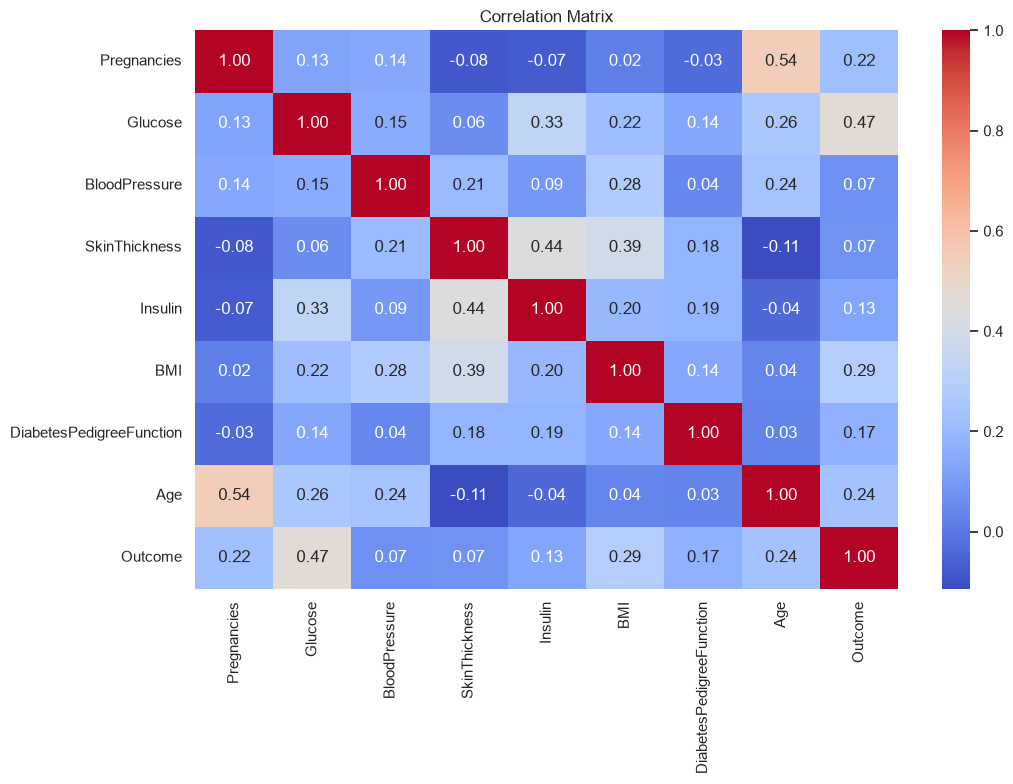


Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [72]:
correlation=data.corr(numeric_only=True)
print("Correlation matrix:")
display(correlation.round(2))
plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../charts/correlation_heatmap.png",
    dpi=300
)
plt.show()
outcome_correlation = (
    correlation["Outcome"]
    .sort_values(ascending=False)
)

print("\nCorrelation with Outcome:")
print(outcome_correlation)

 I am using scatterplots to look at some feature relationships
 visually instead of relying only on the correlation numbers.

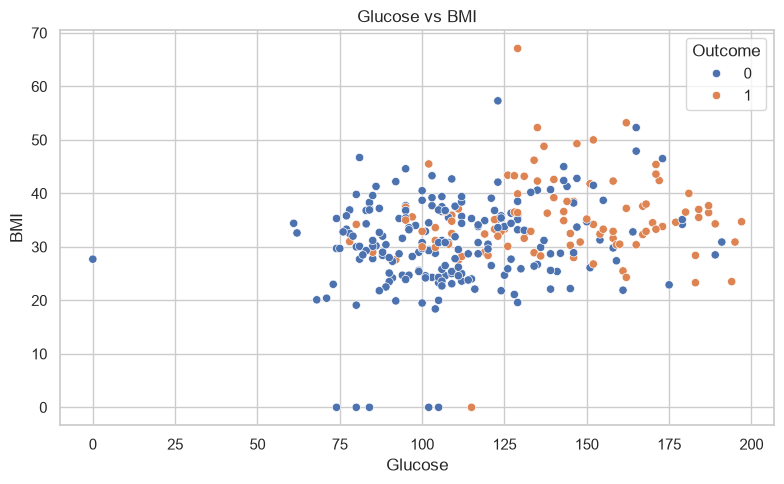

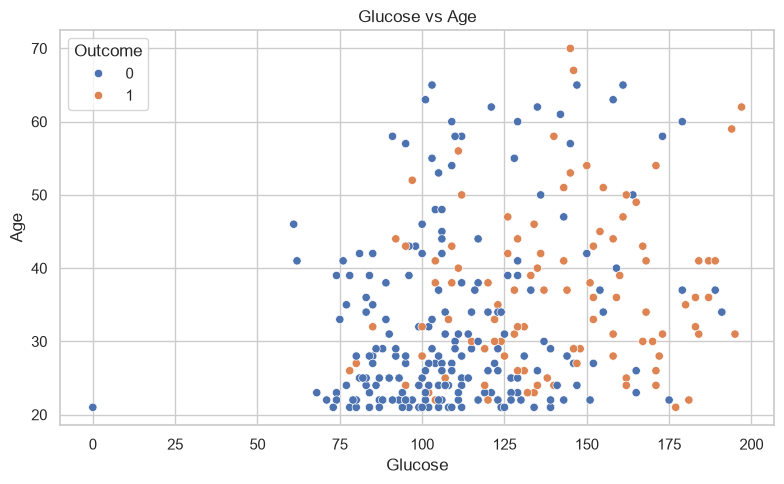

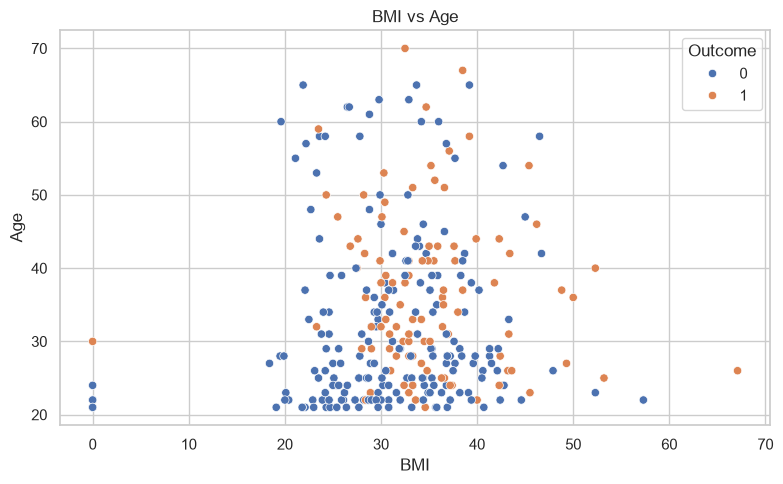

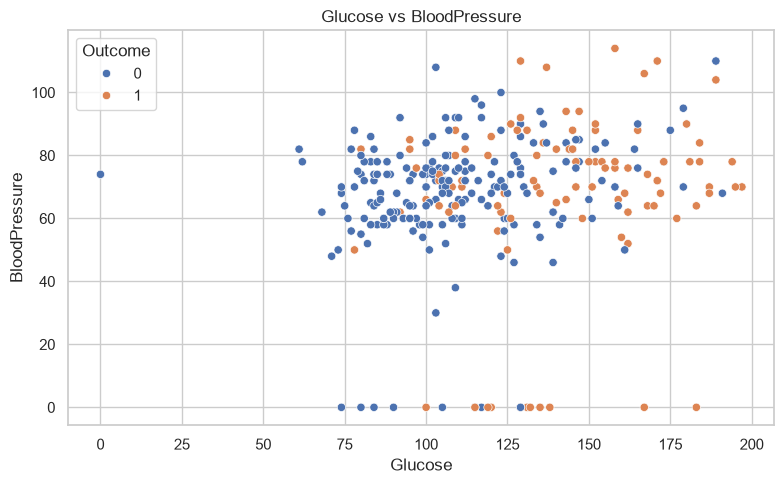

In [73]:
relationships = [
    ("Glucose", "BMI"),
    ("Glucose", "Age"),
    ("BMI", "Age"),
    ("Glucose", "BloodPressure")
]
sample=data.sample(300,random_state=42)
for x_feature, y_feature in relationships:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=sample,
        x=x_feature,
        y=y_feature,
        hue="Outcome"
    )
    plt.title(
        f"{x_feature} vs {y_feature}"
    )
    plt.tight_layout()
    filename = (
        f"../charts/{x_feature.lower()}_"
        f"{y_feature.lower()}_scatter.png"
    )
    plt.savefig(
        filename,
        dpi=300
    )
    plt.show()

 I want to check whether the average glucose level is different
 between the diabetes and non-diabetes groups.

In [74]:
diabetes_group = data.loc[
    data["Outcome"] == 1,
    "Glucose"
]
no_diabetes_group = data.loc[
    data["Outcome"] == 0,
    "Glucose"
]
t_statistic, p_value = stats.ttest_ind(
    diabetes_group,
    no_diabetes_group,
    equal_var=False
)
print("diabetes group mean:",
      diabetes_group.mean())
print("No-diabetes group mean:",
      no_diabetes_group.mean())
print("\nt-statistic:", t_statistic)
print("p-value:", p_value)
# by Using 0.05 as the significance level.
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is evidence of a difference in mean glucose levels.")
else:
    print("Fail to reject the null hypothesis.")

diabetes group mean: 141.25746268656715
No-diabetes group mean: 109.98

t-statistic: 13.751537067396413
p-value: 2.644161349540232e-36
Reject the null hypothesis.
There is evidence of a difference in mean glucose levels.


Calculating a 95% confidence interval for the mean glucose level.

In [75]:
glucose = data["Glucose"]
mean_glucose = glucose.mean()
std_glucose = glucose.std()
n = len(glucose)
standard_error = std_glucose / np.sqrt(n)
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean_glucose,
    scale=standard_error
)
print("Mean glucose:", mean_glucose)
print("Standard deviation:", std_glucose)
print("Standard error:", standard_error)
print(
    "95% confidence interval:",
    confidence_interval
)

Mean glucose: 120.89453125
Standard deviation: 31.97261819513622
Standard error: 1.153712482603689
95% confidence interval: (np.float64(118.62972245094552), np.float64(123.15934004905448))


 Now I am moving from data analysis to machine learning.
 X contains the input features and y contains the value
 that the models will try to predict.

In [76]:
X =data.drop(
    "Outcome",
    axis=1
)
y=data["Outcome"]
print("feature shape:", X.shape)
print("target shape:", y.shape)
print("\nfeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

feature shape: (768, 8)
target shape: (768,)

features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


Split the data into training and testing sets.
 The model learns from the training data and is checked
in order to use later for the testing

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
#it scales the data before the ml learn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nscaled training data shape:",
      X_train_scaled.shape)
print("scaled testing data shape:",
      X_test_scaled.shape)

Training data: (614, 8)
Testing data: (154, 8)

scaled training data shape: (614, 8)
scaled testing data shape: (154, 8)


In [78]:
# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000
)
logistic_model.fit(
    X_train_scaled,
    y_train
)
logistic_prediction = logistic_model.predict(
    X_test_scaled
)
# Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
tree_model.fit(
    X_train,
    y_train
)
tree_prediction = tree_model.predict(
    X_test
)
# Random Forest
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
forest_model.fit(
    X_train,
    y_train
)
forest_prediction = forest_model.predict(
    X_test
)
# Support Vector Machine
svm_model = SVC(
    probability=True
)
svm_model.fit(
    X_train_scaled,
    y_train
)
svm_prediction = svm_model.predict(
    X_test_scaled
)
# Keep all model predictions together.
models_predictions = {
    "Logistic Regression": logistic_prediction,
    "Decision Tree": tree_prediction,
    "Random Forest": forest_prediction,
    "SVM": svm_prediction
}
print("All models trained successfully.")

All models trained successfully.


c:\Users\HP\Documents\Python\ml_algorithm\diabestes _prediciton\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.714,0.609,0.519,0.560
1,Decision Tree,0.799,0.745,0.648,0.693
2,Random Forest,0.760,0.681,0.593,0.634
3,SVM,0.753,0.660,0.611,0.635


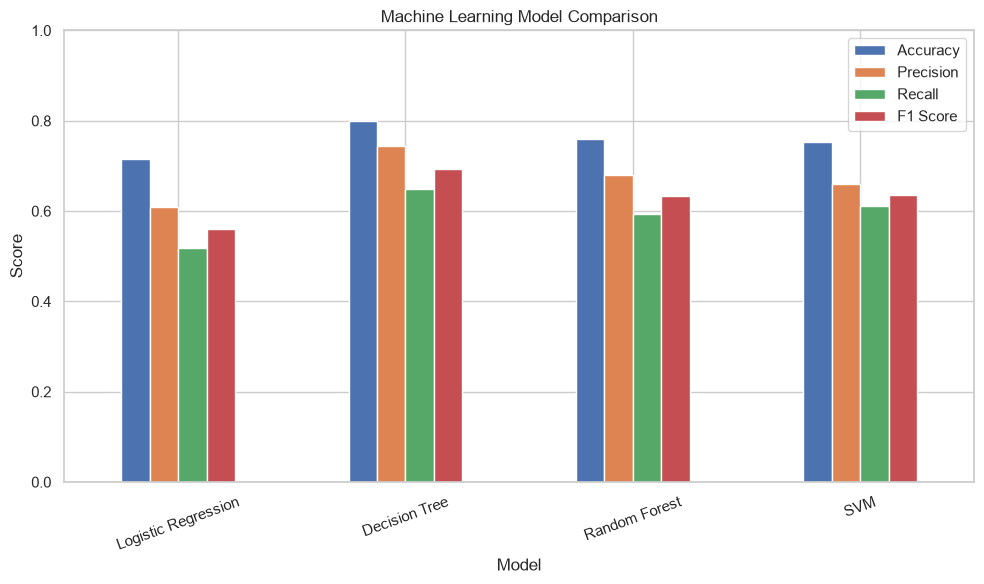

In [80]:
#Now I want to compare the models using more than just accuracy.
# Precision, recall, and F1 score give a better view of the results.
results = []
for name, prediction in models_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction
        ),
        "Recall": recall_score(
            y_test,
            prediction
        ),
        "F1 Score": f1_score(
            y_test,
            prediction
        )
    })

results_df = pd.DataFrame(results)
print("Model Performance:")
display(
    results_df.round(3)
)
#so let as figure the model in oreder to understand easily
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "../charts/model_comparison.png",
    dpi=300
)
plt.show()

deccition tree
Training: 0.7964169381107492
Testing : 0.7987012987012987

random forest
Training: 1.0
Testing : 0.7597402597402597


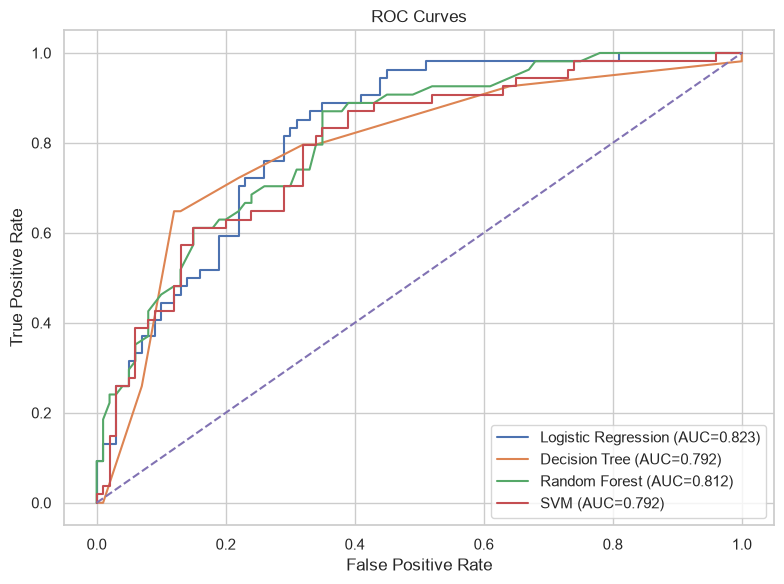

In [82]:
#so now let as compare the treaing data and the test data in order to check the data is ovverfitting
print("deccition tree")
print(
    "Training:",
    tree_model.score(X_train, y_train)
)
print(
    "Testing :",
    tree_model.score(X_test, y_test)
)
print("\nrandom forest")
print(
    "Training:",
    forest_model.score(X_train, y_train)
)
print(
    "Testing :",
    forest_model.score(X_test, y_test)
)
logistic_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]
tree_probability = tree_model.predict_proba(
    X_test
)[:, 1]
forest_probability = forest_model.predict_proba(
    X_test
)[:, 1]
svm_probability = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

probabilities = {
    "Logistic Regression": logistic_probability,
    "Decision Tree": tree_probability,
    "Random Forest": forest_probability,
    "SVM": svm_probability
}
plt.figure(figsize=(8, 6))
for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )
    auc_score = roc_auc_score(
        y_test,
        probability
    )
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../charts/roc_curves.png",
    dpi=300
)
plt.show()

#test the models by using the new data based on the before one training data 

In [83]:
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [130],
    "BloodPressure": [70],
    "SkinThickness": [25],
    "Insulin": [100],
    "BMI": [30],
    "DiabetesPedigreeFunction": [0.5],
    "Age": [35]
})
new_patient_scaled = scaler.transform(
    new_patient
)
prediction = logistic_model.predict(
    new_patient_scaled
)
probability = logistic_model.predict_proba(
    new_patient_scaled
)[0, 1]
print("Prediction:", prediction[0])
print("Probability of class 1:", probability)
if prediction[0] == 1:
    print("Model prediction: Diabetes")
else:
    print("Model prediction: No Diabetes")

Prediction: 0
Probability of class 1: 0.28904374536577976
Model prediction: No Diabetes
